# California Housing Price Prediction using Linear Regression and Neural Networks


# Step 1: Load the Dataset

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# charger le dataset
housing = fetch_california_housing()

# transformer les données en tableau (DataFrame)
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# ajouter la variable cible (prix des maisons)
df["Price"] = housing.target

# afficher les premières lignes
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


(20640, 9)

# Step 2: Data Exploration

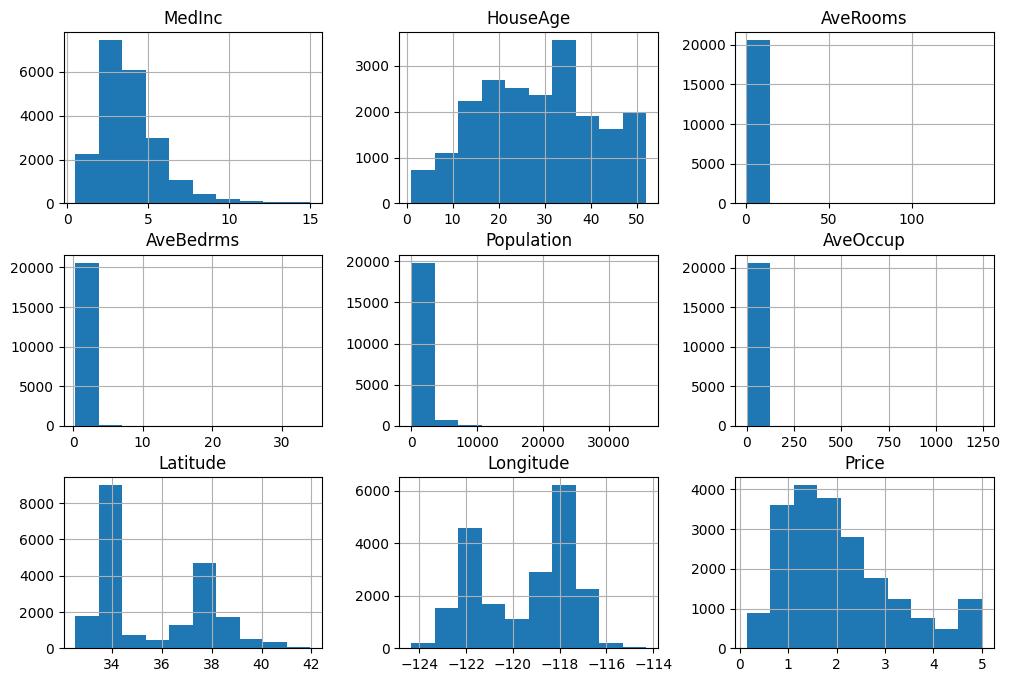

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

### Step 3: Correlation Analysis

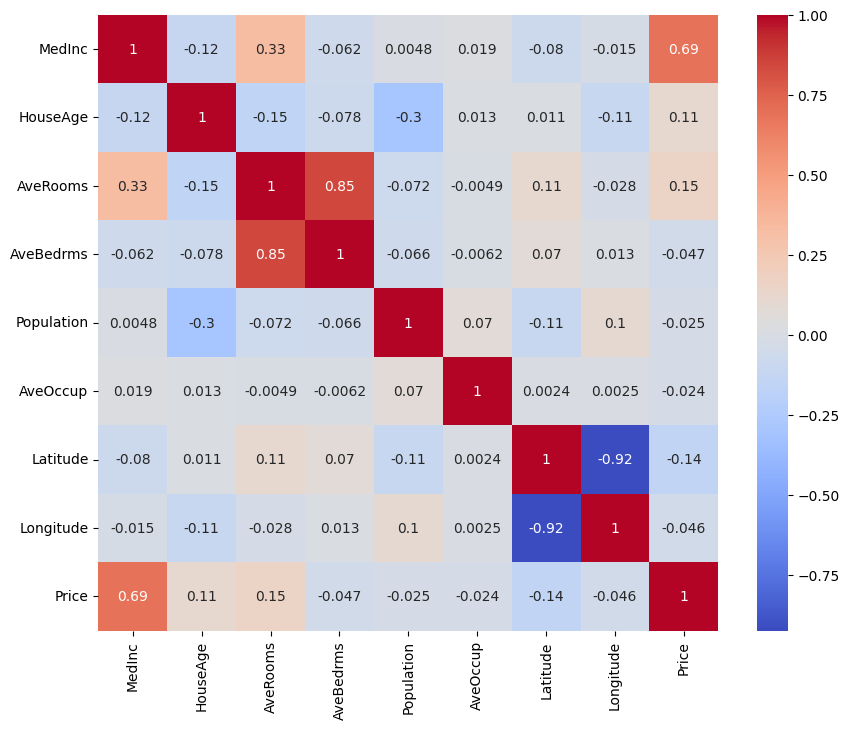

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Step 4: Data Preparation

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

print(X.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


### Feature Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 5: Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


### Linear Regression Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.5332001304956565
MSE: 0.5558915986952442
R2 Score: 0.575787706032451


### Step 6: Neural Network Model

### Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model_nn = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

### Model Compilation

In [ ]:
model_nn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

### Training the Neural Network

In [ ]:
history = model_nn.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7932 - mae: 0.9526 - val_loss: 0.5325 - val_mae: 0.5178
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4587 - mae: 0.4786 - val_loss: 0.4313 - val_mae: 0.4781
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3910 - mae: 0.4435 - val_loss: 0.4126 - val_mae: 0.4493
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3800 - mae: 0.4333 - val_loss: 0.3883 - val_mae: 0.4523
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3495 - mae: 0.4156 - val_loss: 0.3629 - val_mae: 0.4267
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3287 - mae: 0.4033 - val_loss: 0.3850 - val_mae: 0.4149
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3758 - mae: 0.4107 - val_loss: 0.3521 - val_mae: 0.4149
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3300 - mae: 0.3996 - val_loss: 0.3412 - val_mae: 0.4007
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

### Neural Network Evaluation

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# predictions
y_pred_nn = model_nn.predict(X_test).reshape(-1)

# metrics
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("NN - MAE:", mae_nn)
print("NN - MSE:", mse_nn)
print("NN - R2:", r2_nn)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 843us/step
NN - MAE: 0.37118033082640794
NN - MSE: 0.2995537360085723
NN - R2: 0.7714043928402452


### Step 7: Hyperparameter Experiments

In diesem Abschnitt untersuchen wir, wie sich verschiedene Hyperparameter auf die Leistung des neuronalen Netzwerks auswirken.


Hier testen wir ein größeres neuronales Netzwerk, um zu sehen, ob ein komplexeres Modell bessere Ergebnisse liefert.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# größeres neuronales Netzwerk mit mehr Schichten und mehr Neuronen
model_test_1 = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Modell kompilieren
model_test_1.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Modell trainieren
history_test_1 = model_test_1.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6876 - mae: 0.9176 - val_loss: 0.4356 - val_mae: 0.4548
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3743 - mae: 0.4338 - val_loss: 0.4120 - val_mae: 0.4704
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3509 - mae: 0.4244 - val_loss: 0.3901 - val_mae: 0.4252
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3551 - mae: 0.4075 - val_loss: 0.3537 - val_mae: 0.4244
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3191 - mae: 0.3946 - val_loss: 0.3275 - val_mae: 0.4068
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3038 - mae: 0.3823 - val_loss: 0.3347 - val_mae: 0.3910
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3096 - mae: 0.3820 - val_loss: 0.3204 - val_mae: 0.3869
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2968 - mae: 0.3792 - val_loss: 0.3190 - val_mae: 0.3839
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [ ]:
# Vorhersagen mit dem neuen Modell
y_pred_test1 = model_test_1.predict(X_test).reshape(-1)

# Metriken berechnen
mae_test1 = mean_absolute_error(y_test, y_pred_test1)
mse_test1 = mean_squared_error(y_test, y_pred_test1)
r2_test1 = r2_score(y_test, y_pred_test1)

print("Test Model 1 - MAE:", mae_test1)
print("Test Model 1 - MSE:", mse_test1)
print("Test Model 1 - R2:", r2_test1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Test Model 1 - MAE: 0.36049590874455006
Test Model 1 - MSE: 0.2760664750740002
Test Model 1 - R2: 0.7893280039605701


### Hyperparameter Test: Different Optimizer

In diesem Experiment testen wir einen anderen Optimierungsalgorithmus (RMSprop), um zu untersuchen, wie sich der Optimierer auf die Modellleistung auswirkt.

In [ ]:
# neuronales Netzwerk mit anderem Optimizer (RMSprop)

model_test_2 = keras.Sequential([
    keras.Input(shape=(8,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Modell kompilieren mit RMSprop
model_test_2.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

# Modell trainieren
history_test_2 = model_test_2.fit(
    X_train,
    y_train,
    epochs=30,
    validation_split=0.2
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8783 - mae: 0.6359 - val_loss: 0.4105 - val_mae: 0.4582
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3960 - mae: 0.4423 - val_loss: 0.4004 - val_mae: 0.4637
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4029 - mae: 0.4219 - val_loss: 0.3828 - val_mae: 0.4487
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3684 - mae: 0.4024 - val_loss: 0.3352 - val_mae: 0.3910
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3273 - mae: 0.3948 - val_loss: 0.3359 - val_mae: 0.3873
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3139 - mae: 0.3821 - val_loss: 0.3211 - val_mae: 0.3870
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3147 - mae: 0.3848 - val_loss: 0.3274 - val_mae: 0.3810
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4771 - mae: 0.3769 - val_loss: 0.3091 - val_mae: 0.3803
Epoch 9/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [ ]:
# Vorhersagen mit dem dritten Modell
y_pred_test2 = model_test_2.predict(X_test).reshape(-1)

# Metriken berechnen
mae_test2 = mean_absolute_error(y_test, y_pred_test2)
mse_test2 = mean_squared_error(y_test, y_pred_test2)
r2_test2 = r2_score(y_test, y_pred_test2)

print("Test Model 2 - MAE:", mae_test2)
print("Test Model 2 - MSE:", mse_test2)
print("Test Model 2 - R2:", r2_test2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step
Test Model 2 - MAE: 0.363273617951498
Test Model 2 - MSE: 0.277568673282057
Test Model 2 - R2: 0.7881816456609854


## Step 8: Model Comparison and Conclusion

In this project we compared a Linear Regression model with several Neural Network architectures. The results show that neural networks significantly outperform linear regression for this prediction task. The best model achieved an R² score of approximately 0.79.